# EDA optimizado - Resultados Saber 11

**Contexto:** Este notebook realiza un Análisis Exploratorio de Datos optimizado sobre la muestra del dataset Saber 11.

El objetivo es identificar problemas de calidad de datos, valores nulos, variables constantes, alta cardinalidad, distribución del target y posibles estrategias de imputación/preprocesamiento para un problema de clasificación multiclase.

In [1]:
# ============================================================
# CELDA 1 - LIBRERÍAS Y CONFIGURACIÓN GENERAL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

SEED = 42


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [36]:
# ============================================================
# CELDA 2 - RUTAS DE TRABAJO
# ============================================================

RUTA_DATASET = "/content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/DataSetInicial.csv"
RUTA_OUTPUT = "/content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/"

NOMBRE_RESUMEN_EDA = "Resumen_EDA_Saber11.csv"
NOMBRE_RECOMENDACIONES = "Columas a Eliminar.csv"


In [4]:
# ============================================================
# CELDA 3 - CARGA DEL DATASET
# ============================================================

df = pd.read_csv(RUTA_DATASET)

print("Dimensiones del dataset:", df.shape)
display(df.head())


Dimensiones del dataset: (566241, 33)


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,cole_sede_principal,estu_depto_presentacion,estu_depto_reside,estu_estadoinvestigacion,estu_estudiante,estu_genero,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,target
0,20224,TI,SB11202240536228,URBANO,N,A,TÉCNICO/ACADÉMICO,CAQUETA,MIXTO,UNICA,EL DONCELLO,OFICIAL,S,CAQUETA,CAQUETA,PUBLICAR,ESTUDIANTE,F,EL DONCELLO,EL DONCELLO,COLOMBIA,COLOMBIA,N,Cuatro,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,No,Si,Nivel 2: Mínimo
1,20224,TI,SB11202240549969,URBANO,N,A,TÉCNICO/ACADÉMICO,QUINDIO,MIXTO,MAÑANA,ARMENIA,OFICIAL,S,QUINDIO,QUINDIO,PUBLICAR,ESTUDIANTE,F,ARMENIA,ARMENIA,COLOMBIA,COLOMBIA,N,Dos,Educación profesional completa,No Aplica,Estrato 2,3 a 4,No,No,Si,Si,Nivel 2: Mínimo
2,20211,TI,SB11202110001547,RURAL,S,B,ACADÉMICO,CUNDINAMARCA,MIXTO,COMPLETA,SOPÓ,NO OFICIAL,S,CUNDINAMARCA,CUNDINAMARCA,PUBLICAR,ESTUDIANTE,M,ZIPAQUIRÁ,CHÍA,COLOMBIA,COLOMBIA,N,Tres,Educación profesional completa,Postgrado,Estrato 4,3 a 4,Si,Si,Si,Si,Nivel 3: Satisfactorio
3,20211,CR,SB11202110021004,URBANO,NaN,A,ACADÉMICO,CUNDINAMARCA,MIXTO,MAÑANA,TENJO,NO OFICIAL,S,CUNDINAMARCA,CUNDINAMARCA,PUBLICAR,ESTUDIANTE,M,FACATATIVÁ,COTA,COLOMBIA,COLOMBIA,N,Tres,Educación profesional completa,Educación profesional completa,Estrato 5,1 a 2,Si,Si,Si,Si,Nivel 3: Satisfactorio
4,20224,TI,SB11202240101947,RURAL,NaN,A,NO APLICA,ANTIOQUIA,MIXTO,COMPLETA,ANDES,OFICIAL,N,ANTIOQUIA,ANTIOQUIA,PUBLICAR,ESTUDIANTE,M,ANDES,ANDES,COLOMBIA,COLOMBIA,N,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,3 a 4,No,No,No,No,Nivel 3: Satisfactorio


## 1. Diagnóstico general del dataset

Se revisan tipos de datos, cantidad de registros, columnas, valores nulos, valores únicos y posibles problemas iniciales de calidad.

In [5]:
# ============================================================
# CELDA 4 - RESUMEN GENERAL DE VARIABLES
# ============================================================

resumen = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().sum() / len(df) * 100).round(2),
    "valores_unicos": df.nunique(dropna=True),
    "porcentaje_unicos": (df.nunique(dropna=True) / len(df) * 100).round(2)
}).sort_values(["porcentaje_nulos", "valores_unicos"], ascending=[False, False])

display(resumen)


,tipo_dato,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos
cole_bilingue,object,102581,18.12,2,0.00
fami_estratovivienda,object,37482,6.62,7,0.00
fami_tieneinternet,object,33074,5.84,2,0.00
fami_educacionmadre,object,32446,5.73,12,0.00
fami_educacionpadre,object,32320,5.71,12,0.00
fami_tieneautomovil,object,25858,4.57,2,0.00
fami_cuartoshogar,object,24959,4.41,6,0.00
fami_tienelavadora,object,24864,4.39,2,0.00
fami_tienecomputador,object,24778,4.38,2,0.00
fami_personashogar,object,24062,4.25,5,0.00


## 2. Identificación de variables por tipo

Se separan variables categóricas y numéricas. En este dataset predominan variables categóricas, por lo que el análisis se enfoca especialmente en cardinalidad, frecuencia y relación con el target.

In [6]:
# ============================================================
# CELDA 6 - IDENTIFICACIÓN DE VARIABLES
# ============================================================

TARGET_COL = "target"

cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print(f"Variables categóricas: {len(cat_cols)}")
print(cat_cols)
print("Variables numéricas:", len(num_cols))
print(num_cols)

if TARGET_COL not in df.columns:
    print(f"Advertencia: no se encontró la variable target '{TARGET_COL}'.")


Variables categóricas: 32
['estu_tipodocumento', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_bilingue', 'cole_calendario', 'cole_caracter', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_genero', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'target']
Variables numéricas: 1
['periodo']


## 3. Análisis de valores nulos

Este bloque permite identificar columnas candidatas a eliminación o imputación. Como criterio inicial:

- Más de 30% de nulos: evaluar eliminación o tratamiento especial.
- Entre 10% y 30%: imputación cuidadosa.
- Menos de 10%: imputación simple, usualmente moda para categóricas y mediana para numéricas.

In [7]:
# ============================================================
# CELDA 7 - TABLA DE NULOS
# ============================================================

nulos = resumen[resumen["nulos"] > 0].copy()
display(nulos)

print("Columnas con nulos:", nulos.shape[0])


,tipo_dato,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos
cole_bilingue,object,102581,18.12,2,0.00
fami_estratovivienda,object,37482,6.62,7,0.00
fami_tieneinternet,object,33074,5.84,2,0.00
fami_educacionmadre,object,32446,5.73,12,0.00
fami_educacionpadre,object,32320,5.71,12,0.00
fami_tieneautomovil,object,25858,4.57,2,0.00
fami_cuartoshogar,object,24959,4.41,6,0.00
fami_tienelavadora,object,24864,4.39,2,0.00
fami_tienecomputador,object,24778,4.38,2,0.00
fami_personashogar,object,24062,4.25,5,0.00


Columnas con nulos: 22


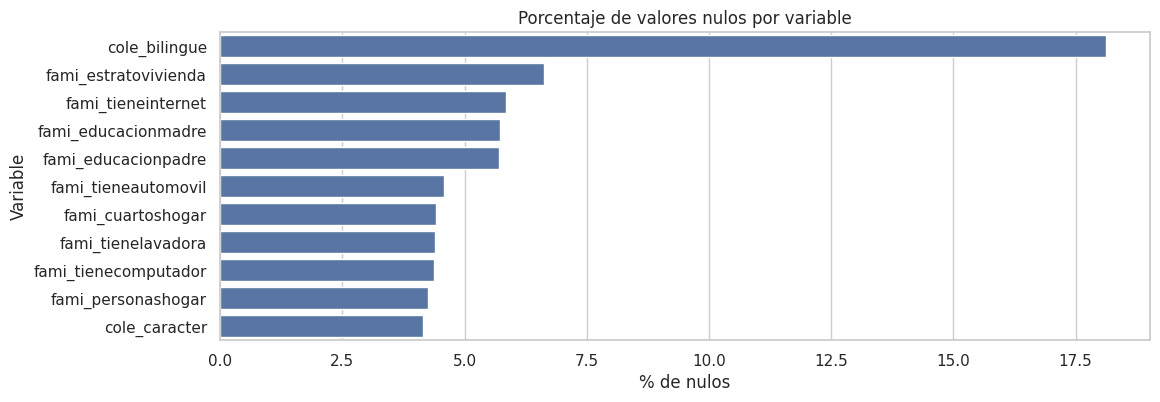

In [8]:
# ============================================================
# CELDA 8 - GRÁFICA OPTIMIZADA DE NULOS
# ============================================================

nulos_plot = nulos[nulos["porcentaje_nulos"] > 0].sort_values("porcentaje_nulos", ascending=False)

if len(nulos_plot) > 0:
    plt.figure(figsize=(12, max(4, len(nulos_plot) * 0.35)))
    sns.barplot(
        data=nulos_plot.reset_index().rename(columns={"index": "variable"}),
        y="variable",
        x="porcentaje_nulos"
    )
    plt.title("Porcentaje de valores nulos por variable")
    plt.xlabel("% de nulos")
    plt.ylabel("Variable")
    plt.show()
else:
    print("No se encontraron valores nulos en el dataset.")


## 4. Variables constantes y casi constantes

Las columnas constantes no aportan información al modelo. Las casi constantes pueden inducir bajo poder predictivo y aumentar ruido.

In [9]:
# ============================================================
# CELDA 9 - VARIABLES CONSTANTES Y CASI CONSTANTES
# ============================================================

cols_constantes = resumen[resumen["valores_unicos"] <= 1].index.tolist()

# Casi constantes: una categoría domina el 95% o más de los registros
cols_casi_constantes = []
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq >= 0.98 and col not in cols_constantes:
        cols_casi_constantes.append(col)

print("Columnas constantes:")
print(cols_constantes)

print("Columnas casi constantes >= 95% en una sola categoría/valor:")
print(cols_casi_constantes)


Columnas constantes:
['estu_estudiante']
Columnas casi constantes >= 95% en una sola categoría/valor:
['estu_estadoinvestigacion', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad']


## 5. Cardinalidad de variables categóricas

La cardinalidad es crítica para decidir estrategias de codificación. Variables con alta cardinalidad pueden requerir agrupación, target encoding, embeddings o eliminación si son identificadores.

In [10]:
# ============================================================
# CELDA 10 - CARDINALIDAD CATEGÓRICA
# ============================================================

cat_cols_sin_target = [c for c in cat_cols if c != TARGET_COL]

cardinalidad = df[cat_cols_sin_target].nunique(dropna=True).sort_values(ascending=False)

cardinalidad_df = pd.DataFrame({
    "variable": cardinalidad.index,
    "cardinalidad": cardinalidad.values
})

cardinalidad_df["grupo_cardinalidad"] = pd.cut(
    cardinalidad_df["cardinalidad"],
    bins=[-1, 10, 50, np.inf],
    labels=["Baja", "Media", "Alta"]
)

display(cardinalidad_df)


,variable,cardinalidad,grupo_cardinalidad
0,estu_consecutivo,566241,Alta
1,estu_mcpio_reside,1034,Alta
2,cole_mcpio_ubicacion,1030,Alta
3,estu_mcpio_presentacion,500,Alta
4,estu_pais_reside,54,Alta
5,estu_nacionalidad,54,Alta
6,estu_depto_reside,34,Media
7,cole_depto_ubicacion,33,Media
8,estu_depto_presentacion,33,Media
9,estu_tipodocumento,15,Media


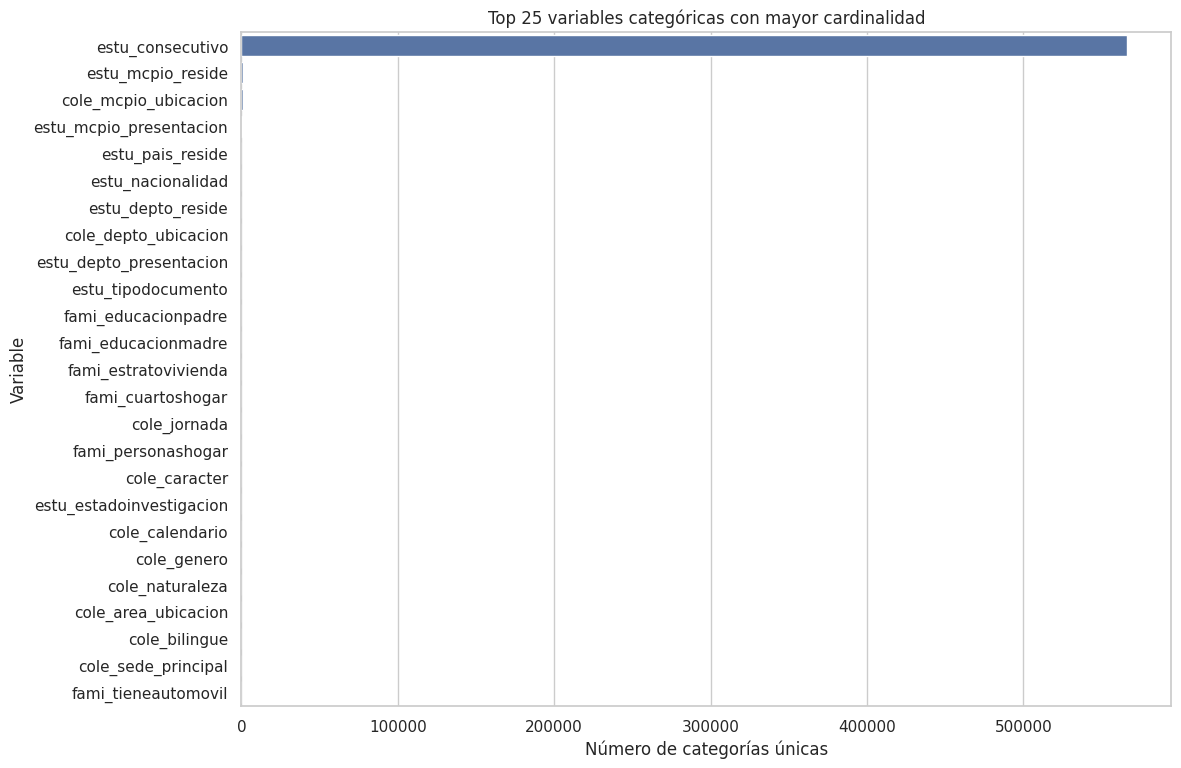

In [11]:
# ============================================================
# CELDA 11 - GRÁFICA DE CARDINALIDAD
# ============================================================

if len(cardinalidad_df) > 0:
    top_card = cardinalidad_df.head(25)
    plt.figure(figsize=(12, max(5, len(top_card) * 0.35)))
    sns.barplot(data=top_card, y="variable", x="cardinalidad")
    plt.title("Top 25 variables categóricas con mayor cardinalidad")
    plt.xlabel("Número de categorías únicas")
    plt.ylabel("Variable")
    plt.show()
else:
    print("No se encontraron variables categóricas para analizar cardinalidad.")


## 6. Distribución del target

Se revisa el balance de clases. Un target desbalanceado puede requerir estrategias como `class_weight`, submuestreo, sobremuestreo o métricas robustas como F1 macro.

,registros,porcentaje
target,,
Nivel 2: Mínimo,268741,47.46
Nivel 3: Satisfactorio,170346,30.08
Nivel 1: Insuficiente,104523,18.46
Nivel 4: Avanzado,22631,4.00


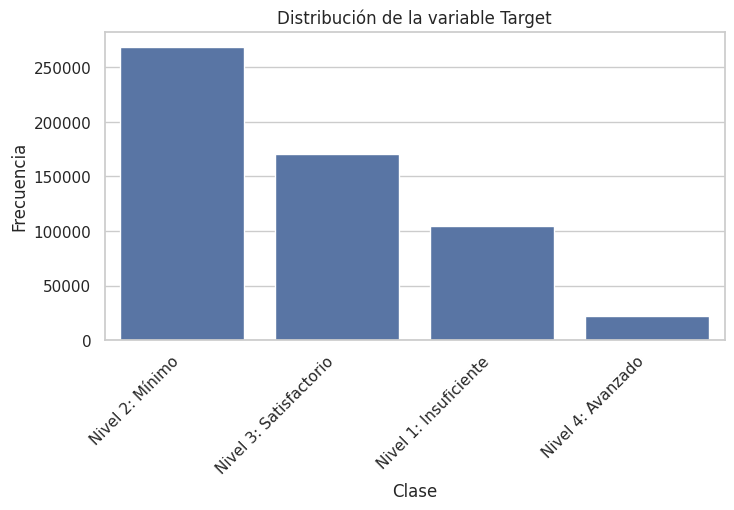

In [12]:
# ============================================================
# CELDA 12 - DISTRIBUCIÓN DEL TARGET
# ============================================================

if TARGET_COL in df.columns:
    target_counts = df[TARGET_COL].value_counts(dropna=False)
    target_pct = (df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100).round(2)

    target_resumen = pd.DataFrame({
        "registros": target_counts,
        "porcentaje": target_pct
    })

    display(target_resumen)

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=TARGET_COL, order=target_counts.index)
    plt.title("Distribución de la variable Target")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia")
    plt.show()
else:
    print(f"No existe la columna {TARGET_COL}. Se omite este análisis.")


## 7. Análisis categórico optimizado

Para evitar sobrecarga computacional, se grafican solo variables categóricas de baja cardinalidad. Para variables de cardinalidad media o alta se generan tablas resumidas con las categorías más frecuentes.

In [13]:
# ============================================================
# CELDA 13 - VARIABLES CATEGÓRICAS DE BAJA CARDINALIDAD
# ============================================================

cat_baja = cardinalidad_df.loc[cardinalidad_df["grupo_cardinalidad"] == "Baja", "variable"].tolist()
cat_media = cardinalidad_df.loc[cardinalidad_df["grupo_cardinalidad"] == "Media", "variable"].tolist()
cat_alta = cardinalidad_df.loc[cardinalidad_df["grupo_cardinalidad"] == "Alta", "variable"].tolist()

print("Categóricas de baja cardinalidad:", len(cat_baja))
print(cat_baja)
print("Categóricas de media cardinalidad:", len(cat_media))
print(cat_media)
print("Categóricas de alta cardinalidad:", len(cat_alta))
print(cat_alta)


Categóricas de baja cardinalidad: 19
['fami_estratovivienda', 'fami_cuartoshogar', 'cole_jornada', 'fami_personashogar', 'cole_caracter', 'estu_estadoinvestigacion', 'cole_calendario', 'cole_genero', 'cole_naturaleza', 'cole_area_ubicacion', 'cole_bilingue', 'cole_sede_principal', 'fami_tieneautomovil', 'estu_genero', 'estu_privado_libertad', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tienelavadora', 'estu_estudiante']
Categóricas de media cardinalidad: 6
['estu_depto_reside', 'cole_depto_ubicacion', 'estu_depto_presentacion', 'estu_tipodocumento', 'fami_educacionpadre', 'fami_educacionmadre']
Categóricas de alta cardinalidad: 6
['estu_consecutivo', 'estu_mcpio_reside', 'cole_mcpio_ubicacion', 'estu_mcpio_presentacion', 'estu_pais_reside', 'estu_nacionalidad']


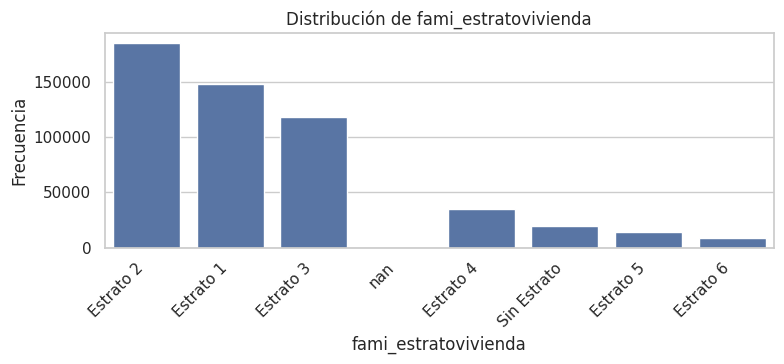

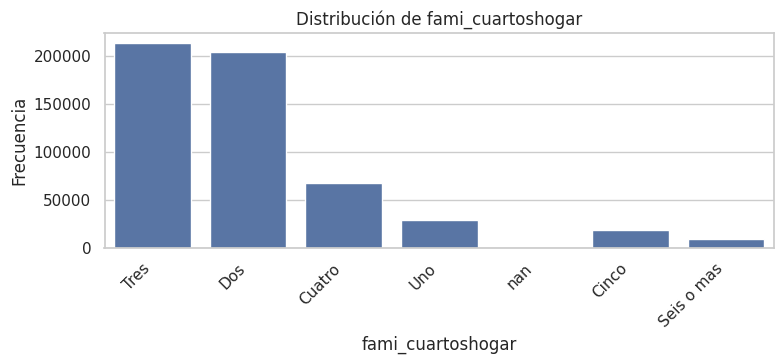

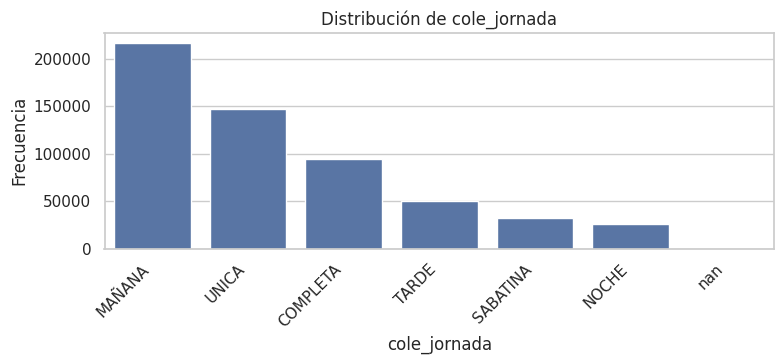

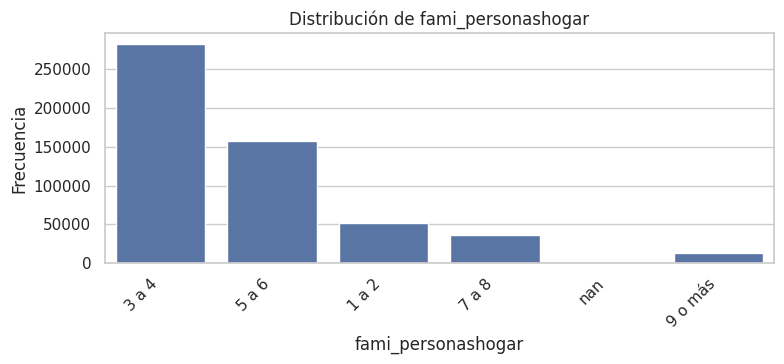

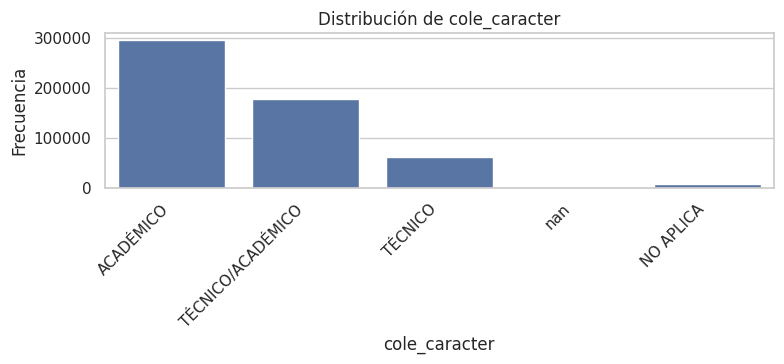

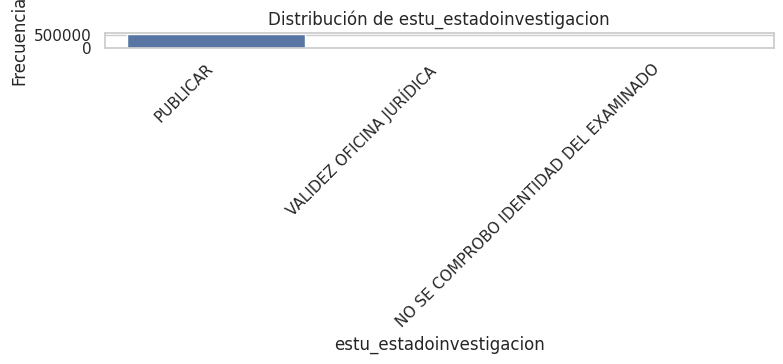

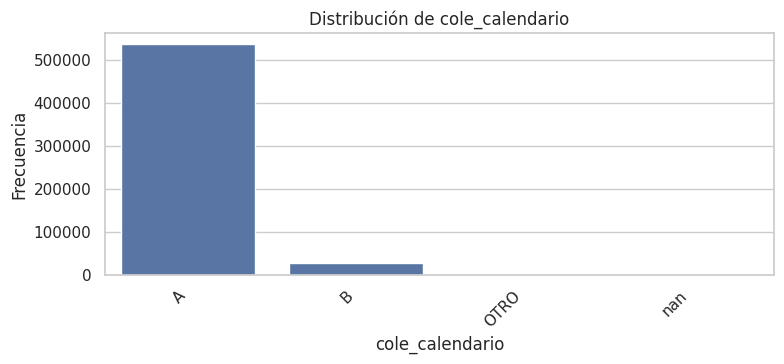

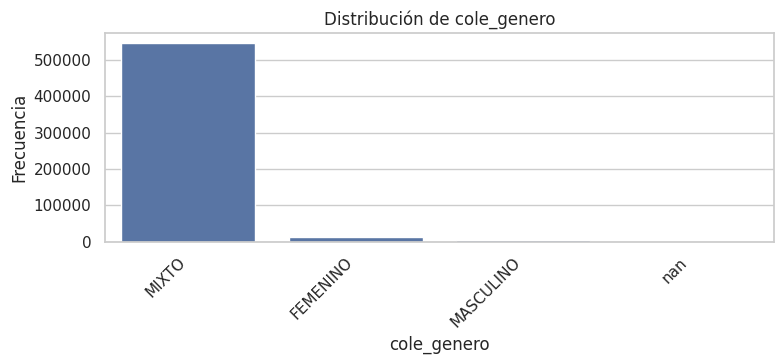

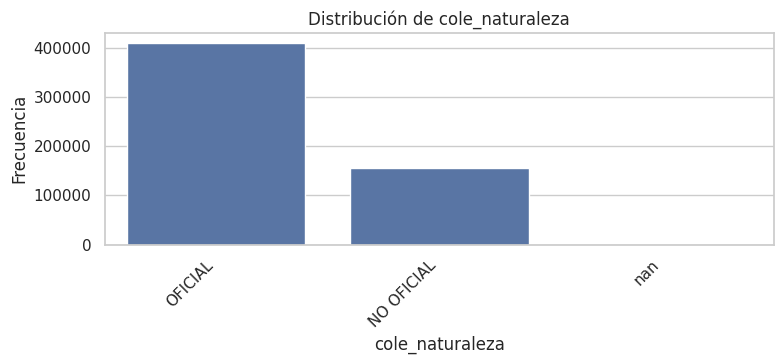

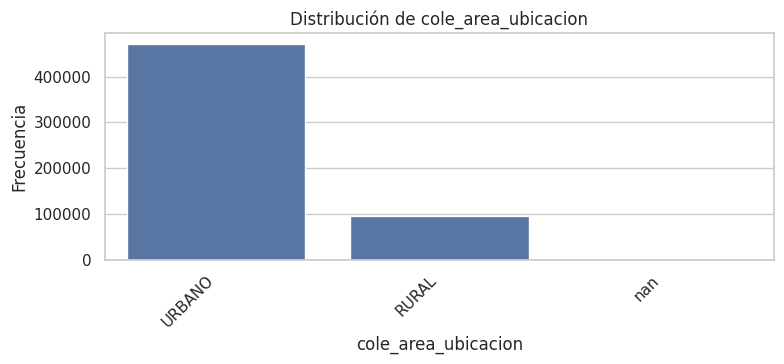

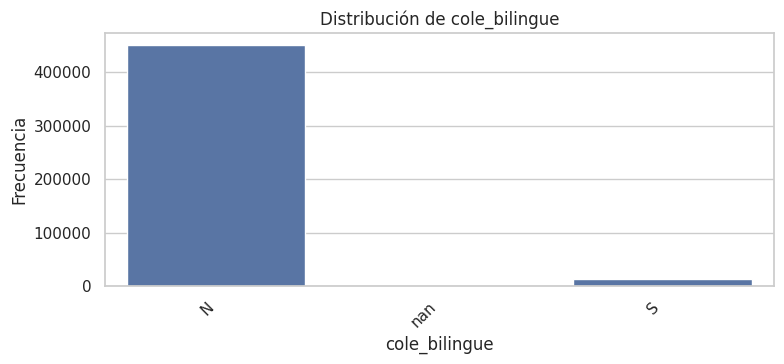

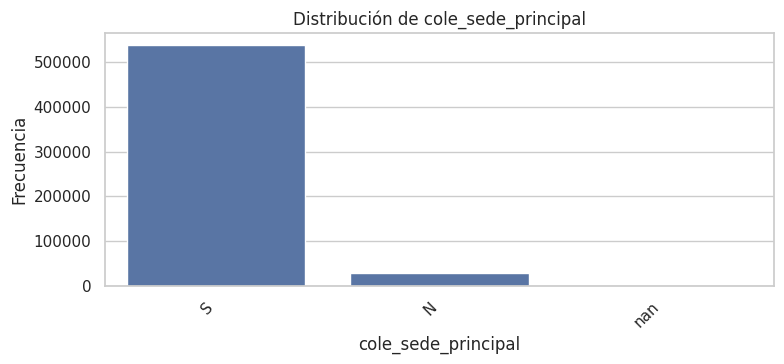

In [14]:
# ============================================================
# CELDA 14 - GRÁFICAS CATEGÓRICAS DE BAJA CARDINALIDAD
# ============================================================

MAX_GRAFICAS_CAT = 12

for col in cat_baja[:MAX_GRAFICAS_CAT]:
    plt.figure(figsize=(8, 3.8))
    orden = df[col].value_counts(dropna=False).index
    sns.countplot(data=df, x=col, order=orden)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


In [15]:
# ============================================================
# CELDA 15 - TOP CATEGORÍAS EN VARIABLES DE MEDIA/ALTA CARDINALIDAD
# ============================================================

for col in (cat_media + cat_alta)[:15]:
    print("=" * 90)
    print(f"Variable: {col} | Categorías únicas: {df[col].nunique(dropna=True)}")
    display(df[col].value_counts(dropna=False).head(12).to_frame("frecuencia"))


Variable: estu_depto_reside | Categorías únicas: 34


,frecuencia
estu_depto_reside,
BOGOTÁ,85396
ANTIOQUIA,74427
VALLE,53559
CUNDINAMARCA,36161
ATLANTICO,32424
BOLIVAR,27613
SANTANDER,24997
CORDOBA,22214
NARIÑO,17659


Variable: cole_depto_ubicacion | Categorías únicas: 33


,frecuencia
cole_depto_ubicacion,
BOGOTÁ,84370
ANTIOQUIA,74058
VALLE,53533
CUNDINAMARCA,37497
ATLANTICO,32591
BOLIVAR,27736
SANTANDER,25381
CORDOBA,22264
NARIÑO,17615


Variable: estu_depto_presentacion | Categorías únicas: 33


...

,frecuencia
estu_mcpio_presentacion,
BOGOTÁ D.C.,85769
CALI,28804
MEDELLÍN,28049
BARRANQUILLA,19051
CARTAGENA DE INDIAS,15680
CÚCUTA,10022
SOACHA,7930
IBAGUÉ,7441
BUCARAMANGA,7379


Variable: estu_pais_reside | Categorías únicas: 54


,frecuencia
estu_pais_reside,
COLOMBIA,558999
VENEZUELA,6803
ECUADOR,81
ESPAÑA,59
ESTADOS UNIDOS,53
PERÚ,23
ARGENTINA,19
BRASIL,18
VANUATU,17


Variable: estu_nacionalidad | Categorías únicas: 54


,frecuencia
estu_nacionalidad,
COLOMBIA,558999
VENEZUELA,6803
ECUADOR,81
ESPAÑA,59
ESTADOS UNIDOS,53
PERÚ,23
ARGENTINA,19
BRASIL,18
VANUATU,17


## 8. Relación entre variables categóricas y Target

Se analizan cruces con el target únicamente en variables de baja cardinalidad para mantener eficiencia y legibilidad.

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
fami_estratovivienda,,,,
Estrato 1,21.08,54.20,23.38,1.34
Estrato 2,15.14,51.06,31.29,2.51
Estrato 3,13.09,43.70,38.26,4.95
Estrato 4,15.46,31.58,40.26,12.69
Estrato 5,15.73,24.10,40.22,19.95
Estrato 6,15.92,16.61,42.74,24.73
Sin Estrato,45.95,43.16,9.97,0.91


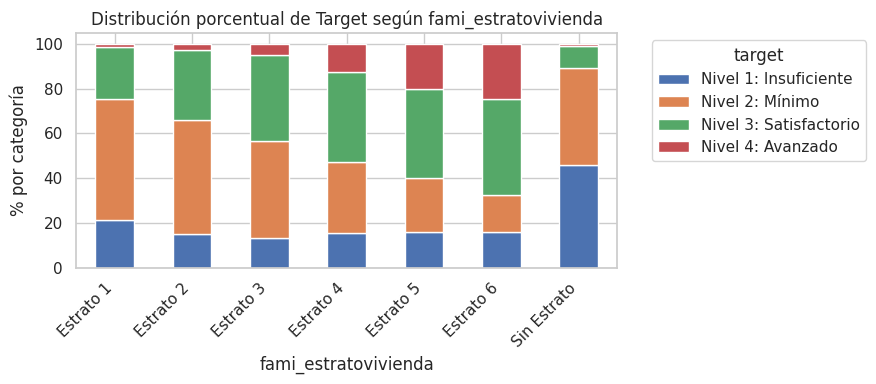

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
fami_cuartoshogar,,,,
Cinco,24.87,45.62,26.04,3.47
Cuatro,20.29,46.27,29.05,4.39
Dos,17.67,49.36,29.57,3.40
Seis o mas,31.41,43.12,23.49,1.98
Tres,15.50,46.15,33.24,5.10
Uno,27.51,49.59,21.34,1.57


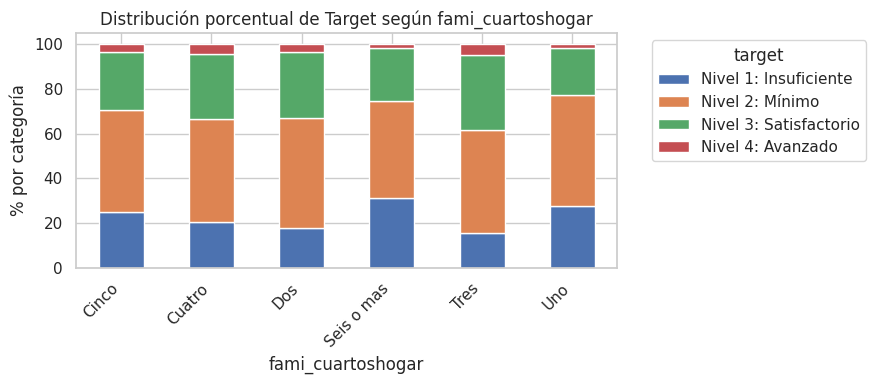

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
cole_jornada,,,,
COMPLETA,6.96,31.08,48.19,13.78
MAÑANA,18.85,49.84,28.71,2.60
NOCHE,44.70,47.57,7.58,0.15
SABATINA,42.01,49.70,8.13,0.16
TARDE,19.22,53.05,26.30,1.43
UNICA,15.29,52.06,30.49,2.15


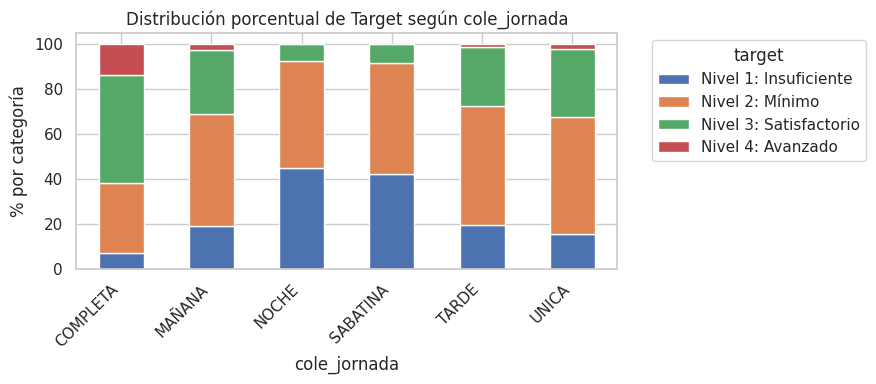

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
fami_personashogar,,,,
1 a 2,20.59,46.88,28.72,3.81
3 a 4,14.56,46.18,34.16,5.09
5 a 6,19.77,49.73,27.34,3.16
7 a 8,28.20,49.79,20.52,1.49
9 o más,36.18,45.94,16.66,1.22


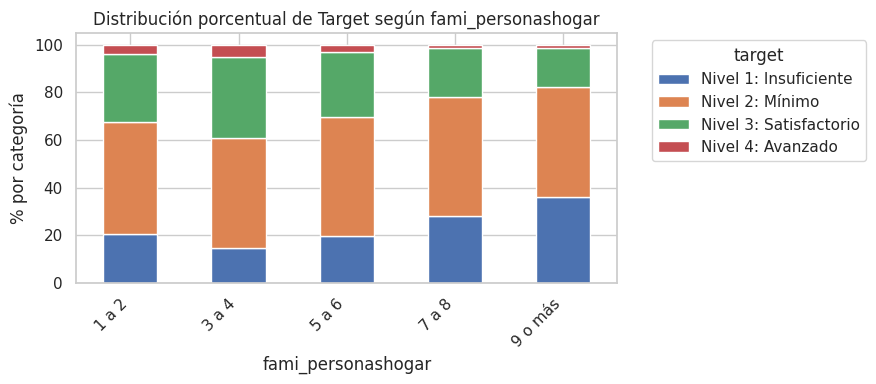

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
cole_caracter,,,,
ACADÉMICO,17.02,45.04,32.26,5.69
NO APLICA,29.27,44.39,24.07,2.27
TÉCNICO,21.03,50.07,26.88,2.01
TÉCNICO/ACADÉMICO,18.31,50.44,29.04,2.21


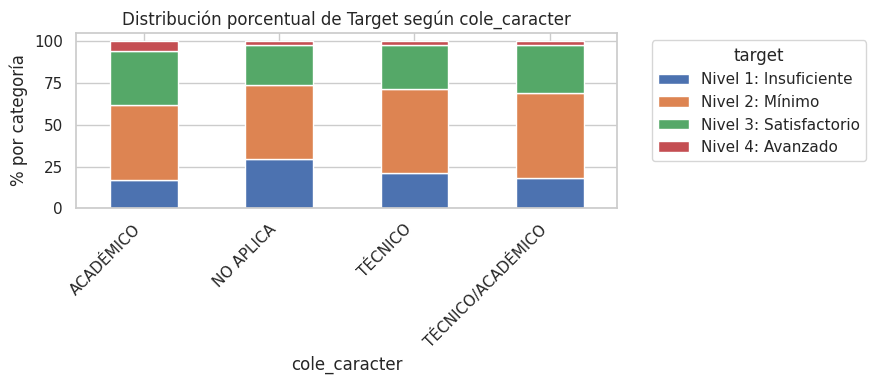

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
estu_estadoinvestigacion,,,,
NO SE COMPROBO IDENTIDAD DEL EXAMINADO,0.00,0.00,100.00,0.00
PUBLICAR,18.46,47.46,30.09,4.00
VALIDEZ OFICINA JURÍDICA,12.81,57.44,25.62,4.13


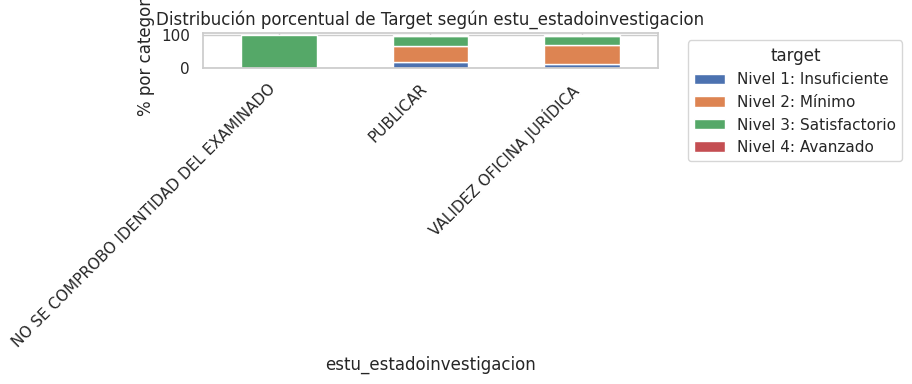

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
cole_calendario,,,,
A,19.22,48.82,28.98,2.98
B,3.02,20.58,52.38,24.02
OTRO,23.82,52.33,22.50,1.35


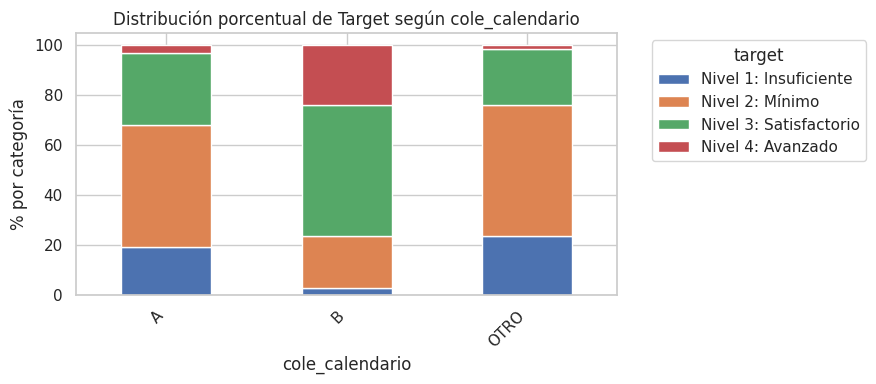

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
cole_genero,,,,
FEMENINO,4.39,31.30,53.63,10.67
MASCULINO,5.22,22.73,51.02,21.03
MIXTO,18.94,48.10,29.29,3.67


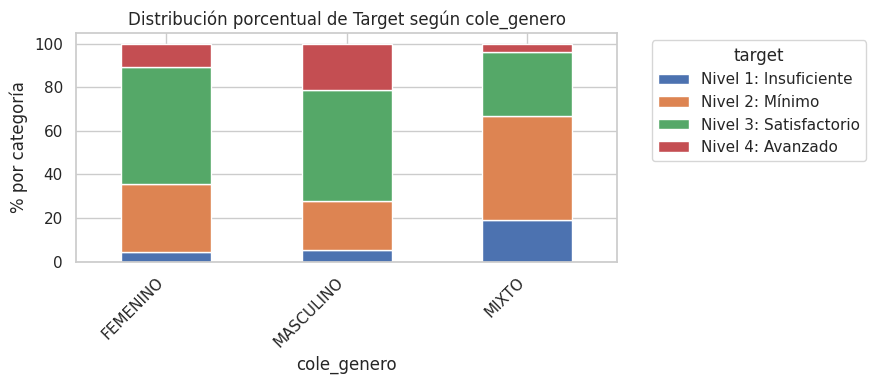

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
cole_naturaleza,,,,
NO OFICIAL,11.61,35.15,42.66,10.58
OFICIAL,21.05,52.11,25.34,1.51


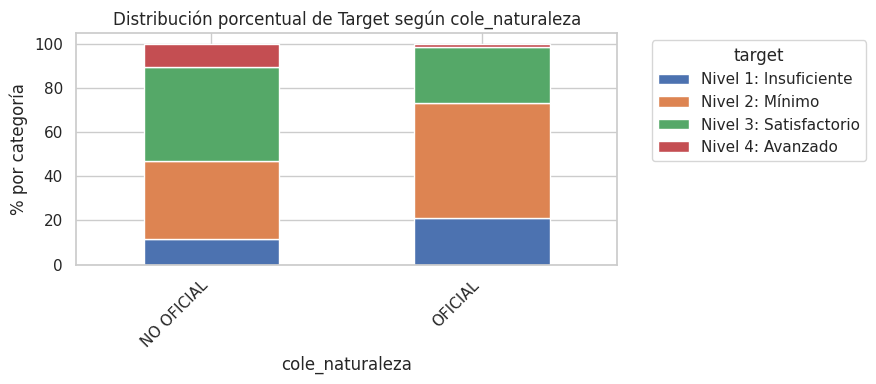

target,Nivel 1: Insuficiente,Nivel 2: Mínimo,Nivel 3: Satisfactorio,Nivel 4: Avanzado
cole_area_ubicacion,,,,
RURAL,30.53,48.53,18.31,2.62
URBANO,16.05,47.25,32.44,4.27


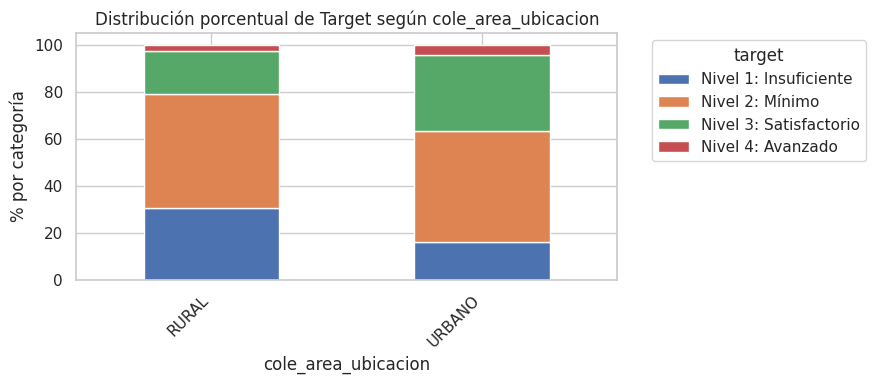

In [16]:
# ============================================================
# CELDA 16 - CATEGÓRICAS VS TARGET
# ============================================================

if TARGET_COL in df.columns:
    for col in cat_baja[:10]:
        tabla = pd.crosstab(df[col], df[TARGET_COL], normalize="index") * 100
        display(tabla.round(2))

        tabla.plot(kind="bar", stacked=True, figsize=(9, 4))
        plt.title(f"Distribución porcentual de Target según {col}")
        plt.ylabel("% por categoría")
        plt.xlabel(col)
        plt.xticks(rotation=45, ha="right")
        plt.legend(title=TARGET_COL, bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
else:
    print("No se puede hacer cruce categórico porque no existe Target.")


## 9. Analisis de asociación
CUando tenemos variables categoricas no podemos hablar de correlacion pues esta aplica solo para variables numericas. En este caso, para evaluar la asociación entre variables categóricas se utilizó la V de Cramér,
acompañada de la prueba chi-cuadrado de independencia. La variable objetivo fue
excluida del análisis para evitar que la exploración de relaciones entre variables predictoras estuviera condicionada por el target.

Esta primera parte busca un analisis exploratorio que determine la condicion general de los datos en su asociacion

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests


def cramers_v_chi2(
    df,
    target_col,
    columnas_categoricas=None,
    excluir_cols=None,
    alpha=0.05,
    corregir_sesgo=True,
    aplicar_correccion_multiples_pruebas=True,
    metodo_correccion="fdr_bh",
    incluir_nulos=True,
    etiqueta_nulo="SIN_DATO",
    min_frecuencia_categoria=1,
    ordenar_por="v_cramer"
):
    """
    Calcula la asociación entre variables categóricas usando V de Cramér
    y valida significancia estadística mediante prueba chi-cuadrado.

    La variable target se excluye del análisis.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset de entrada.

    target_col : str
        Nombre de la variable objetivo que se debe excluir del análisis.

    columnas_categoricas : list, opcional
        Lista de columnas categóricas a analizar.
        Si es None, se seleccionan automáticamente columnas tipo object, category y bool.

    excluir_cols : list, opcional
        Columnas adicionales a excluir, por ejemplo identificadores.

    alpha : float
        Nivel de significancia estadística. Por defecto 0.05.

    corregir_sesgo : bool
        Si True, aplica corrección de sesgo a la V de Cramér.
        Recomendado para tablas con muchas categorías.

    aplicar_correccion_multiples_pruebas : bool
        Si True, ajusta los p-values por múltiples comparaciones.

    metodo_correccion : str
        Método de ajuste de p-values.
        Por defecto: 'fdr_bh', Benjamini-Hochberg.

    incluir_nulos : bool
        Si True, los valores nulos se tratan como una categoría adicional.

    etiqueta_nulo : str
        Etiqueta usada para representar valores nulos.

    min_frecuencia_categoria : int
        Frecuencia mínima para conservar una categoría.
        Categorías con frecuencia menor se agrupan como 'OTRAS_CATEGORIAS'.

    ordenar_por : str
        Columna para ordenar el resultado.
        Opciones útiles: 'v_cramer', 'p_value', 'p_value_ajustado'.

    Retorna
    -------
    resultados_df : pd.DataFrame
        Tabla larga con pares de variables, V de Cramér, p-value,
        significancia estadística e interpretación.

    matriz_v_cramer : pd.DataFrame
        Matriz simétrica de V de Cramér.
    """

    if target_col not in df.columns:
        raise ValueError(f"La variable target '{target_col}' no existe en el DataFrame.")

    if excluir_cols is None:
        excluir_cols = []

    columnas_excluir = set([target_col] + excluir_cols)

    if columnas_categoricas is None:
        columnas_categoricas = df.select_dtypes(
            include=["object", "category", "bool"]
        ).columns.tolist()

    columnas_categoricas = [
        col for col in columnas_categoricas
        if col in df.columns and col not in columnas_excluir
    ]

    if len(columnas_categoricas) < 2:
        raise ValueError(
            "Se requieren al menos dos variables categóricas, excluyendo el target."
        )

    def preparar_serie(s):
        s = s.copy()

        if incluir_nulos:
            s = s.astype("object").fillna(etiqueta_nulo)
        else:
            s = s.dropna()

        frecuencias = s.value_counts(dropna=False)

        categorias_bajas = frecuencias[
            frecuencias < min_frecuencia_categoria
        ].index

        if len(categorias_bajas) > 0:
            s = s.replace(categorias_bajas, "OTRAS_CATEGORIAS")

        return s.astype(str)

    def calcular_cramers_v(tabla):
        chi2, p_value, dof, expected = chi2_contingency(tabla)

        n = tabla.to_numpy().sum()
        r, k = tabla.shape

        if n == 0 or r < 2 or k < 2:
            return np.nan, np.nan, np.nan, np.nan

        phi2 = chi2 / n

        if corregir_sesgo:
            phi2_corr = max(
                0,
                phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1)
            )

            r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
            k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)

            denominador = min(k_corr - 1, r_corr - 1)

            if denominador <= 0:
                v = np.nan
            else:
                v = np.sqrt(phi2_corr / denominador)

        else:
            denominador = min(k - 1, r - 1)

            if denominador <= 0:
                v = np.nan
            else:
                v = np.sqrt(phi2 / denominador)

        return v, p_value, chi2, dof

    def interpretar_v(v):
        if pd.isna(v):
            return "No calculable"
        elif v < 0.10:
            return "Asociación débil o casi nula"
        elif v < 0.30:
            return "Asociación baja"
        elif v < 0.70:
            return "Asociación moderada"
        else:
            return "Asociación alta"

    resultados = []

    matriz_v_cramer = pd.DataFrame(
        np.eye(len(columnas_categoricas)),
        index=columnas_categoricas,
        columns=columnas_categoricas
    )

    for i, col_1 in enumerate(columnas_categoricas):
        for j, col_2 in enumerate(columnas_categoricas):

            if j <= i:
                continue

            temp = df[[col_1, col_2]].copy()

            if incluir_nulos:
                x = preparar_serie(temp[col_1])
                y = preparar_serie(temp[col_2])
                temp_preparado = pd.DataFrame({col_1: x, col_2: y})
            else:
                temp_preparado = temp.dropna()
                temp_preparado[col_1] = preparar_serie(temp_preparado[col_1])
                temp_preparado[col_2] = preparar_serie(temp_preparado[col_2])

            if temp_preparado[col_1].nunique() < 2 or temp_preparado[col_2].nunique() < 2:
                v, p_value, chi2, dof = np.nan, np.nan, np.nan, np.nan
                n = len(temp_preparado)
                categorias_col_1 = temp_preparado[col_1].nunique()
                categorias_col_2 = temp_preparado[col_2].nunique()
            else:
                tabla = pd.crosstab(
                    temp_preparado[col_1],
                    temp_preparado[col_2]
                )

                v, p_value, chi2, dof = calcular_cramers_v(tabla)
                n = tabla.to_numpy().sum()
                categorias_col_1, categorias_col_2 = tabla.shape

            matriz_v_cramer.loc[col_1, col_2] = v
            matriz_v_cramer.loc[col_2, col_1] = v

            resultados.append({
                "variable_1": col_1,
                "variable_2": col_2,
                "v_cramer": v,
                "interpretacion_v_cramer": interpretar_v(v),
                "chi2": chi2,
                "grados_libertad": dof,
                "p_value": p_value,
                "n_observaciones": n,
                "categorias_variable_1": categorias_col_1,
                "categorias_variable_2": categorias_col_2
            })

    resultados_df = pd.DataFrame(resultados)

    if aplicar_correccion_multiples_pruebas and resultados_df["p_value"].notna().sum() > 0:
        mascara_validos = resultados_df["p_value"].notna()

        _, p_values_ajustados, _, _ = multipletests(
            resultados_df.loc[mascara_validos, "p_value"],
            alpha=alpha,
            method=metodo_correccion
        )

        resultados_df["p_value_ajustado"] = np.nan
        resultados_df.loc[mascara_validos, "p_value_ajustado"] = p_values_ajustados

        resultados_df["relacion_significativa"] = (
            resultados_df["p_value_ajustado"] < alpha
        )

    else:
        resultados_df["p_value_ajustado"] = resultados_df["p_value"]
        resultados_df["relacion_significativa"] = (
            resultados_df["p_value"] < alpha
        )

    resultados_df["decision_estadistica"] = np.where(
        resultados_df["relacion_significativa"],
        "Existe asociación estadísticamente significativa",
        "No hay evidencia estadística suficiente de asociación"
    )

    if ordenar_por in resultados_df.columns:
        ascending = True if ordenar_por in ["p_value", "p_value_ajustado"] else False
        resultados_df = resultados_df.sort_values(
            by=ordenar_por,
            ascending=ascending
        ).reset_index(drop=True)

    return resultados_df, matriz_v_cramer

In [18]:
target_col = "target"

resultados_cramer, matriz_cramer = cramers_v_chi2(
    df=df,
    target_col=target_col,
    excluir_cols=["estu_consecutivo"],
    alpha=0.05,
    corregir_sesgo=True,
    aplicar_correccion_multiples_pruebas=True,
    min_frecuencia_categoria=10
)

In [19]:
resultados_cramer.head(20)

,variable_1,variable_2,v_cramer,interpretacion_v_cramer,chi2,grados_libertad,p_value,n_observaciones,categorias_variable_1,categorias_variable_2,p_value_ajustado,relacion_significativa,decision_estadistica
0,estu_nacionalidad,estu_pais_reside,1.000000,Asociación alta,7.927374e+06,196.0,0.0,566241,15,15,0.0,True,Existe asociación estadísticamente significativa
1,estu_depto_presentacion,estu_mcpio_presentacion,0.990530,Asociación alta,1.779309e+07,15936.0,0.0,566241,33,499,0.0,True,Existe asociación estadísticamente significativa
2,estu_depto_presentacion,estu_depto_reside,0.982412,Asociación alta,1.748805e+07,1088.0,0.0,566241,33,35,0.0,True,Existe asociación estadísticamente significativa
3,cole_depto_ubicacion,estu_depto_presentacion,0.977902,Asociación alta,1.732782e+07,1056.0,0.0,566241,34,33,0.0,True,Existe asociación estadísticamente significativa
4,cole_depto_ubicacion,estu_depto_reside,0.975785,Asociación alta,1.779202e+07,1122.0,0.0,566241,34,35,0.0,True,Existe asociación estadísticamente significativa
5,estu_depto_presentacion,estu_mcpio_reside,0.974351,Asociación alta,1.723405e+07,32896.0,0.0,566241,33,1029,0.0,True,Existe asociación estadísticamente significativa
6,cole_mcpio_ubicacion,estu_depto_presentacion,0.970898,Asociación alta,1.711230e+07,32864.0,0.0,566241,1028,33,0.0,True,Existe asociación estadísticamente significativa
7,estu_depto_reside,estu_mcpio_reside,0.969021,Asociación alta,1.811172e+07,34952.0,0.0,566241,35,1029,0.0,True,Existe asociación estadísticamente significativa
8,cole_depto_ubicacion,cole_mcpio_ubicacion,0.968767,Asociación alta,1.756982e+07,33891.0,0.0,566241,34,1028,0.0,True,Existe asociación estadísticamente significativa
9,cole_depto_ubicacion,estu_mcpio_reside,0.959133,Asociación alta,1.722282e+07,33924.0,0.0,566241,34,1029,0.0,True,Existe asociación estadísticamente significativa


In [20]:
relaciones_fuertes_significativas = resultados_cramer[
    (resultados_cramer["v_cramer"] >= 0.70) &
    (resultados_cramer["relacion_significativa"] == True)
].copy()

relaciones_fuertes_significativas

,variable_1,variable_2,v_cramer,interpretacion_v_cramer,chi2,grados_libertad,p_value,n_observaciones,categorias_variable_1,categorias_variable_2,p_value_ajustado,relacion_significativa,decision_estadistica
0,estu_nacionalidad,estu_pais_reside,1.000000,Asociación alta,7.927374e+06,196.0,0.0,566241,15,15,0.0,True,Existe asociación estadísticamente significativa
1,estu_depto_presentacion,estu_mcpio_presentacion,0.990530,Asociación alta,1.779309e+07,15936.0,0.0,566241,33,499,0.0,True,Existe asociación estadísticamente significativa
2,estu_depto_presentacion,estu_depto_reside,0.982412,Asociación alta,1.748805e+07,1088.0,0.0,566241,33,35,0.0,True,Existe asociación estadísticamente significativa
3,cole_depto_ubicacion,estu_depto_presentacion,0.977902,Asociación alta,1.732782e+07,1056.0,0.0,566241,34,33,0.0,True,Existe asociación estadísticamente significativa
4,cole_depto_ubicacion,estu_depto_reside,0.975785,Asociación alta,1.779202e+07,1122.0,0.0,566241,34,35,0.0,True,Existe asociación estadísticamente significativa
5,estu_depto_presentacion,estu_mcpio_reside,0.974351,Asociación alta,1.723405e+07,32896.0,0.0,566241,33,1029,0.0,True,Existe asociación estadísticamente significativa
6,cole_mcpio_ubicacion,estu_depto_presentacion,0.970898,Asociación alta,1.711230e+07,32864.0,0.0,566241,1028,33,0.0,True,Existe asociación estadísticamente significativa
7,estu_depto_reside,estu_mcpio_reside,0.969021,Asociación alta,1.811172e+07,34952.0,0.0,566241,35,1029,0.0,True,Existe asociación estadísticamente significativa
8,cole_depto_ubicacion,cole_mcpio_ubicacion,0.968767,Asociación alta,1.756982e+07,33891.0,0.0,566241,34,1028,0.0,True,Existe asociación estadísticamente significativa
9,cole_depto_ubicacion,estu_mcpio_reside,0.959133,Asociación alta,1.722282e+07,33924.0,0.0,566241,34,1029,0.0,True,Existe asociación estadísticamente significativa


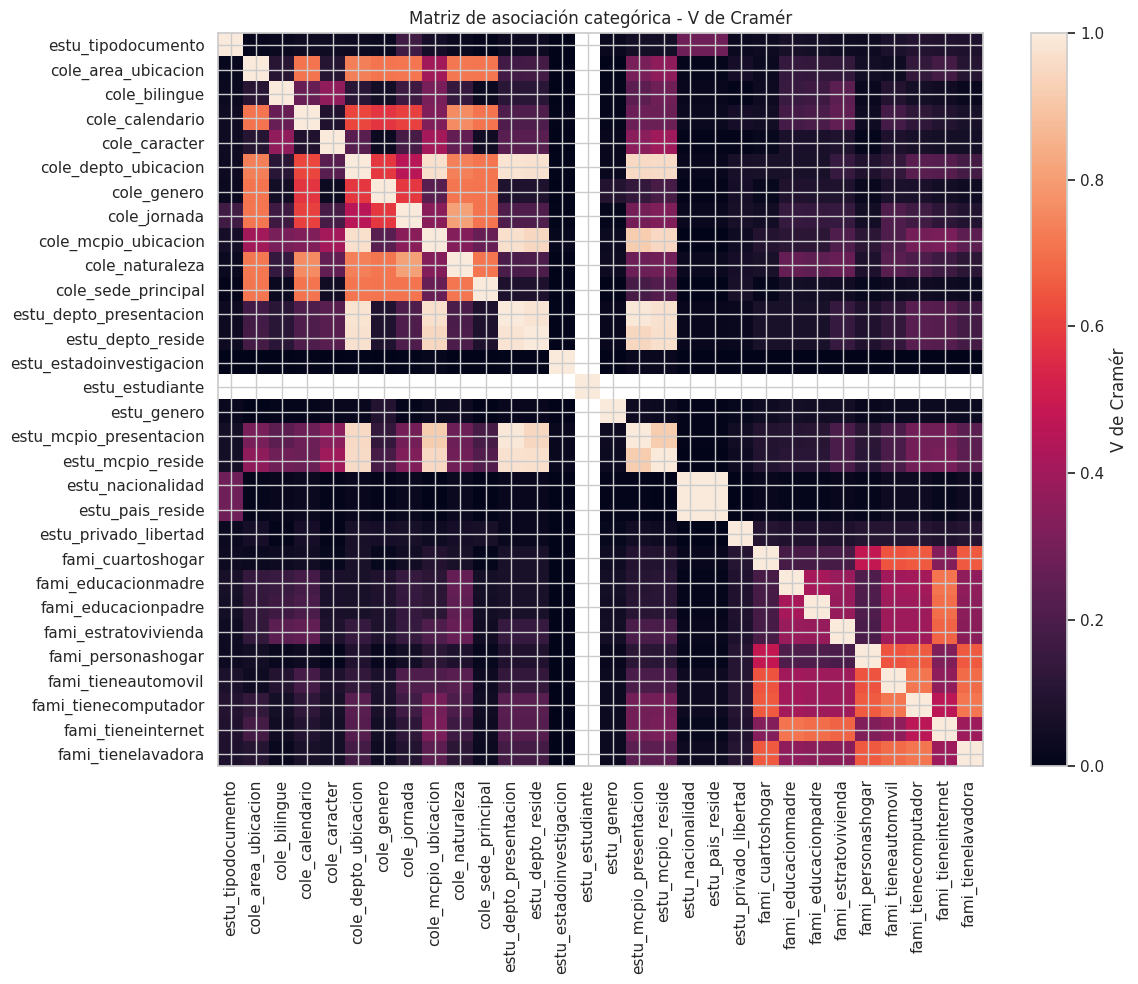

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.imshow(matriz_cramer.astype(float), aspect="auto")
plt.colorbar(label="V de Cramér")

plt.xticks(
    ticks=range(len(matriz_cramer.columns)),
    labels=matriz_cramer.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(matriz_cramer.index)),
    labels=matriz_cramer.index
)

plt.title("Matriz de asociación categórica - V de Cramér")
plt.tight_layout()
plt.show()

## 10. Columnas candidatas a Eliminar por alta asociacion
Dado que se encuentra un grupo importante de variables con alta asociacion, vamos a identificar las columnas con alta asociacion comparando par a par cada una de ellas.  Cuando dos variables presentaron una asociación
superior a 0.70, se eliminó aquella con menor asociación frente a la variable
objetivo.

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


def seleccionar_categoricas_por_cramer_target(
    df,
    target_col,
    columnas_categoricas=None,
    excluir_cols=None,
    umbral_cramer=0.70,
    min_frecuencia_categoria=10,
    incluir_nulos=True,
    etiqueta_nulo="SIN_DATO",
    corregir_sesgo=True,
    verbose=True
):
    """
    Elimina variables categóricas altamente asociadas entre sí usando V de Cramér.

    Lógica:
    1. Toma todas las variables categóricas, excluyendo el target.
    2. Calcula la asociación entre cada par de variables categóricas.
    3. Si V de Cramér entre dos variables es mayor al umbral definido,
       elimina la variable que tenga menor asociación con el target.
    4. Después de eliminar una variable, vuelve a recorrer las columnas restantes.
    5. El proceso termina cuando no existan pares con asociación superior al umbral.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset de entrada.

    target_col : str
        Variable objetivo. Esta columna no se elimina ni se compara como predictora.

    columnas_categoricas : list, opcional
        Lista de columnas categóricas a evaluar.
        Si es None, se seleccionan automáticamente columnas object, category y bool.

    excluir_cols : list, opcional
        Columnas adicionales a excluir, por ejemplo identificadores.

    umbral_cramer : float
        Umbral de V de Cramér para considerar asociación alta entre dos variables.
        Por defecto 0.70.

    min_frecuencia_categoria : int
        Categorías con frecuencia menor a este valor se agrupan como 'OTRAS_CATEGORIAS'.

    incluir_nulos : bool
        Si True, los nulos se tratan como una categoría adicional.

    etiqueta_nulo : str
        Etiqueta para reemplazar valores nulos.

    corregir_sesgo : bool
        Si True, aplica corrección de sesgo a la V de Cramér.

    verbose : bool
        Si True, imprime el avance del proceso.

    Retorna
    -------
    df_reducido : pd.DataFrame
        Dataset sin las variables categóricas eliminadas.

    columnas_conservadas : list
        Variables categóricas conservadas.

    columnas_eliminadas : list
        Variables categóricas eliminadas.

    reporte_eliminacion : pd.DataFrame
        Detalle de cada eliminación realizada.
    """

    if target_col not in df.columns:
        raise ValueError(f"La columna target '{target_col}' no existe en el DataFrame.")

    if excluir_cols is None:
        excluir_cols = []

    columnas_excluir = set([target_col] + excluir_cols)

    if columnas_categoricas is None:
        columnas_categoricas = df.select_dtypes(
            include=["object", "category", "bool"]
        ).columns.tolist()

    columnas_categoricas = [
        col for col in columnas_categoricas
        if col in df.columns and col not in columnas_excluir
    ]

    if len(columnas_categoricas) < 2:
        raise ValueError("Se requieren al menos dos variables categóricas para evaluar asociación.")

    def preparar_serie(s):
        """
        Limpia y prepara una serie categórica.
        """
        s = s.copy()

        if incluir_nulos:
            s = s.astype("object").fillna(etiqueta_nulo)
        else:
            s = s.dropna()

        frecuencias = s.value_counts(dropna=False)

        categorias_poco_frecuentes = frecuencias[
            frecuencias < min_frecuencia_categoria
        ].index

        if len(categorias_poco_frecuentes) > 0:
            s = s.replace(categorias_poco_frecuentes, "OTRAS_CATEGORIAS")

        return s.astype(str)

    def cramers_v(x, y):
        """
        Calcula V de Cramér entre dos variables categóricas.
        """

        temp = pd.DataFrame({
            "x": x,
            "y": y
        })

        if not incluir_nulos:
            temp = temp.dropna()

        if temp.empty:
            return np.nan

        x_preparada = preparar_serie(temp["x"])
        y_preparada = preparar_serie(temp["y"])

        if x_preparada.nunique() < 2 or y_preparada.nunique() < 2:
            return np.nan

        tabla = pd.crosstab(x_preparada, y_preparada)

        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            return np.nan

        chi2, _, _, _ = chi2_contingency(tabla)

        n = tabla.to_numpy().sum()
        r, k = tabla.shape

        if n == 0:
            return np.nan

        phi2 = chi2 / n

        if corregir_sesgo:
            phi2_corr = max(
                0,
                phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1)
            )

            r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
            k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)

            denominador = min(r_corr - 1, k_corr - 1)

            if denominador <= 0:
                return np.nan

            return np.sqrt(phi2_corr / denominador)

        else:
            denominador = min(r - 1, k - 1)

            if denominador <= 0:
                return np.nan

            return np.sqrt(phi2 / denominador)

    def calcular_asociacion_con_target(col):
        """
        Calcula la asociación de una variable categórica con el target.

        Esta versión asume que el target es categórico.
        Si el target es numérico, se recomienda discretizarlo antes.
        """
        return cramers_v(df[col], df[target_col])

    # Asociación de cada variable categórica con el target
    asociacion_target = {
        col: calcular_asociacion_con_target(col)
        for col in columnas_categoricas
    }

    columnas_restantes = columnas_categoricas.copy()
    columnas_eliminadas = []
    reporte = []

    continuar = True
    iteracion = 1

    while continuar:
        continuar = False

        if verbose:
            print(f"\nIteración {iteracion}")
            print(f"Columnas categóricas restantes: {len(columnas_restantes)}")

        for i in range(len(columnas_restantes)):
            col_1 = columnas_restantes[i]

            variable_eliminada_en_iteracion = False

            for j in range(i + 1, len(columnas_restantes)):
                col_2 = columnas_restantes[j]

                v_par = cramers_v(df[col_1], df[col_2])

                if pd.isna(v_par):
                    continue

                if v_par > umbral_cramer:

                    asociacion_target_col_1 = asociacion_target.get(col_1, np.nan)
                    asociacion_target_col_2 = asociacion_target.get(col_2, np.nan)

                    # Si alguna asociación con el target es NaN, se considera menor
                    score_col_1 = -1 if pd.isna(asociacion_target_col_1) else asociacion_target_col_1
                    score_col_2 = -1 if pd.isna(asociacion_target_col_2) else asociacion_target_col_2

                    if score_col_1 < score_col_2:
                        col_eliminar = col_1
                        col_conservar = col_2
                        asociacion_eliminada = asociacion_target_col_1
                        asociacion_conservada = asociacion_target_col_2
                    else:
                        col_eliminar = col_2
                        col_conservar = col_1
                        asociacion_eliminada = asociacion_target_col_2
                        asociacion_conservada = asociacion_target_col_1

                    columnas_restantes.remove(col_eliminar)
                    columnas_eliminadas.append(col_eliminar)

                    reporte.append({
                        "iteracion": iteracion,
                        "variable_1": col_1,
                        "variable_2": col_2,
                        "v_cramer_entre_variables": v_par,
                        "variable_eliminada": col_eliminar,
                        "variable_conservada": col_conservar,
                        "v_cramer_eliminada_vs_target": asociacion_eliminada,
                        "v_cramer_conservada_vs_target": asociacion_conservada,
                        "criterio": (
                            f"Se elimina '{col_eliminar}' por tener menor asociación "
                            f"con el target '{target_col}'"
                        )
                    })

                    if verbose:
                        print(
                            f"Alta asociación detectada: {col_1} vs {col_2} "
                            f"| V de Cramér = {v_par:.4f}"
                        )
                        print(
                            f"Se elimina: {col_eliminar} "
                            f"| Asociación con target = {asociacion_eliminada:.4f}"
                        )
                        print(
                            f"Se conserva: {col_conservar} "
                            f"| Asociación con target = {asociacion_conservada:.4f}"
                        )

                    continuar = True
                    variable_eliminada_en_iteracion = True
                    break

            if variable_eliminada_en_iteracion:
                break

        iteracion += 1

    reporte_eliminacion = pd.DataFrame(reporte)

    columnas_a_eliminar = list(set(columnas_eliminadas))

    df_reducido = df.drop(columns=columnas_a_eliminar).copy()

    if verbose:
        print("\nProceso finalizado")
        print("-" * 50)
        print(f"Columnas categóricas iniciales evaluadas: {len(columnas_categoricas)}")
        print(f"Columnas categóricas eliminadas: {len(columnas_a_eliminar)}")
        print(f"Columnas categóricas conservadas: {len(columnas_restantes)}")

    return df_reducido, columnas_restantes, columnas_a_eliminar, reporte_eliminacion

In [23]:
target_col = "target"

df_reducido, columnas_cat_conservadas, columnas_cat_eliminadas, reporte_eliminacion = seleccionar_categoricas_por_cramer_target(
    df=df,
    target_col=target_col,
    excluir_cols=["estu_consecutivo"],
    umbral_cramer=0.70,
    min_frecuencia_categoria=10,
    incluir_nulos=True,
    corregir_sesgo=True,
    verbose=True
)


Iteración 1
Columnas categóricas restantes: 30
Alta asociación detectada: cole_area_ubicacion vs cole_calendario | V de Cramér = 0.7072
Se elimina: cole_area_ubicacion | Asociación con target = 0.1140
Se conserva: cole_calendario | Asociación con target = 0.1572

Iteración 2
Columnas categóricas restantes: 29
Alta asociación detectada: cole_calendario vs cole_naturaleza | V de Cramér = 0.7579
Se elimina: cole_calendario | Asociación con target = 0.1572
Se conserva: cole_naturaleza | Asociación con target = 0.2030

Iteración 3
Columnas categóricas restantes: 28
Alta asociación detectada: cole_depto_ubicacion vs cole_mcpio_ubicacion | V de Cramér = 0.9688
Se elimina: cole_depto_ubicacion | Asociación con target = 0.1543
Se conserva: cole_mcpio_ubicacion | Asociación con target = 0.2304

Iteración 4
Columnas categóricas restantes: 27
Alta asociación detectada: cole_genero vs cole_naturaleza | V de Cramér = 0.7119
Se elimina: cole_genero | Asociación con target = 0.0847
Se conserva: cole_

In [24]:
columnas_cat_eliminadas

['cole_naturaleza',
 'cole_area_ubicacion',
 'cole_genero',
 'estu_mcpio_presentacion',
 'fami_tieneinternet',
 'estu_depto_presentacion',
 'fami_tieneautomovil',
 'cole_depto_ubicacion',
 'estu_depto_reside',
 'fami_tienelavadora',
 'estu_mcpio_reside',
 'estu_pais_reside',
 'cole_sede_principal',
 'cole_calendario']

In [25]:
reporte_eliminacion.sort_values(
    by="v_cramer_entre_variables",
    ascending=False
)

,iteracion,variable_1,variable_2,v_cramer_entre_variables,variable_eliminada,variable_conservada,v_cramer_eliminada_vs_target,v_cramer_conservada_vs_target,criterio
10,11,estu_nacionalidad,estu_pais_reside,1.000000,estu_pais_reside,estu_nacionalidad,0.019471,0.019471,Se elimina 'estu_pais_reside' por tener menor ...
6,7,cole_mcpio_ubicacion,estu_depto_presentacion,0.970898,estu_depto_presentacion,cole_mcpio_ubicacion,0.156229,0.230435,Se elimina 'estu_depto_presentacion' por tener...
2,3,cole_depto_ubicacion,cole_mcpio_ubicacion,0.968767,cole_depto_ubicacion,cole_mcpio_ubicacion,0.154293,0.230435,Se elimina 'cole_depto_ubicacion' por tener me...
9,10,cole_mcpio_ubicacion,estu_mcpio_reside,0.949524,estu_mcpio_reside,cole_mcpio_ubicacion,0.224894,0.230435,Se elimina 'estu_mcpio_reside' por tener menor...
7,8,cole_mcpio_ubicacion,estu_depto_reside,0.945732,estu_depto_reside,cole_mcpio_ubicacion,0.157207,0.230435,Se elimina 'estu_depto_reside' por tener menor...
8,9,cole_mcpio_ubicacion,estu_mcpio_presentacion,0.921125,estu_mcpio_presentacion,cole_mcpio_ubicacion,0.217161,0.230435,Se elimina 'estu_mcpio_presentacion' por tener...
4,5,cole_jornada,cole_naturaleza,0.809867,cole_naturaleza,cole_jornada,0.203045,0.218966,Se elimina 'cole_naturaleza' por tener menor a...
1,2,cole_calendario,cole_naturaleza,0.757938,cole_calendario,cole_naturaleza,0.157202,0.203045,Se elimina 'cole_calendario' por tener menor a...
12,13,fami_tieneautomovil,fami_tienecomputador,0.714468,fami_tieneautomovil,fami_tienecomputador,0.180824,0.216678,Se elimina 'fami_tieneautomovil' por tener men...
3,4,cole_genero,cole_naturaleza,0.711852,cole_genero,cole_naturaleza,0.084721,0.203045,Se elimina 'cole_genero' por tener menor asoci...


Construimos una nueva matriz de Cramer para examinar como se asocian las variables resultantes

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


def graficar_matriz_cramer_dataset_resultante(
    df,
    columnas_categoricas=None,
    target_col=None,
    excluir_cols=None,
    min_frecuencia_categoria=10,
    incluir_nulos=True,
    etiqueta_nulo="SIN_DATO",
    corregir_sesgo=True,
    figsize=None,
    annot=True,
    cmap="Blues",
    triangular=True,
    titulo="Matriz de asociación categórica - V de Cramér"
):



    if excluir_cols is None:
        excluir_cols = []

    columnas_excluir = set(excluir_cols)

    if target_col is not None:
        columnas_excluir.add(target_col)

    if columnas_categoricas is None:
        columnas_categoricas = df.select_dtypes(
            include=["object", "category", "bool"]
        ).columns.tolist()

    columnas_categoricas = [
        col for col in columnas_categoricas
        if col in df.columns and col not in columnas_excluir
    ]

    if len(columnas_categoricas) < 2:
        raise ValueError(
            "Se requieren al menos dos variables categóricas para construir la matriz."
        )

    def preparar_serie(s):
        """
        Prepara una serie categórica para calcular V de Cramér.
        """
        s = s.copy()

        if incluir_nulos:
            s = s.astype("object").fillna(etiqueta_nulo)
        else:
            s = s.dropna()

        frecuencias = s.value_counts(dropna=False)

        categorias_poco_frecuentes = frecuencias[
            frecuencias < min_frecuencia_categoria
        ].index

        if len(categorias_poco_frecuentes) > 0:
            s = s.replace(categorias_poco_frecuentes, "OTRAS_CATEGORIAS")

        return s.astype(str)

    def calcular_cramers_v(x, y):
        """
        Calcula V de Cramér entre dos variables categóricas.
        """
        temp = pd.DataFrame({
            "x": x,
            "y": y
        })

        if not incluir_nulos:
            temp = temp.dropna()

        if temp.empty:
            return np.nan

        x_preparada = preparar_serie(temp["x"])
        y_preparada = preparar_serie(temp["y"])

        if x_preparada.nunique() < 2 or y_preparada.nunique() < 2:
            return np.nan

        tabla = pd.crosstab(x_preparada, y_preparada)

        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            return np.nan

        chi2, _, _, _ = chi2_contingency(tabla)

        n = tabla.to_numpy().sum()
        r, k = tabla.shape

        if n == 0:
            return np.nan

        phi2 = chi2 / n

        if corregir_sesgo:
            phi2_corr = max(
                0,
                phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1)
            )

            r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
            k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)

            denominador = min(r_corr - 1, k_corr - 1)

            if denominador <= 0:
                return np.nan

            return np.sqrt(phi2_corr / denominador)

        else:
            denominador = min(r - 1, k - 1)

            if denominador <= 0:
                return np.nan

            return np.sqrt(phi2 / denominador)

    # Crear matriz vacía
    matriz_cramer = pd.DataFrame(
        np.eye(len(columnas_categoricas)),
        index=columnas_categoricas,
        columns=columnas_categoricas,
        dtype=float
    )

    # Calcular V de Cramér para cada par de variables
    for i, col_1 in enumerate(columnas_categoricas):
        for j, col_2 in enumerate(columnas_categoricas):

            if j <= i:
                continue

            v = calcular_cramers_v(df[col_1], df[col_2])

            matriz_cramer.loc[col_1, col_2] = v
            matriz_cramer.loc[col_2, col_1] = v

    # Tamaño automático de figura
    if figsize is None:
        n_cols = len(columnas_categoricas)
        figsize = (
            max(10, n_cols * 0.8),
            max(8, n_cols * 0.7)
        )

    # Máscara triangular opcional
    if triangular:
        mask = np.triu(np.ones_like(matriz_cramer, dtype=bool))
    else:
        mask = None

    # Graficar heatmap
    plt.figure(figsize=figsize)

    sns.heatmap(
        matriz_cramer.astype(float),
        mask=mask,
        annot=annot,
        fmt=".2f",
        cmap=cmap,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        square=True,
        cbar_kws={"label": "V de Cramér"}
    )

    plt.title(titulo, fontsize=14, fontweight="bold")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return matriz_cramer

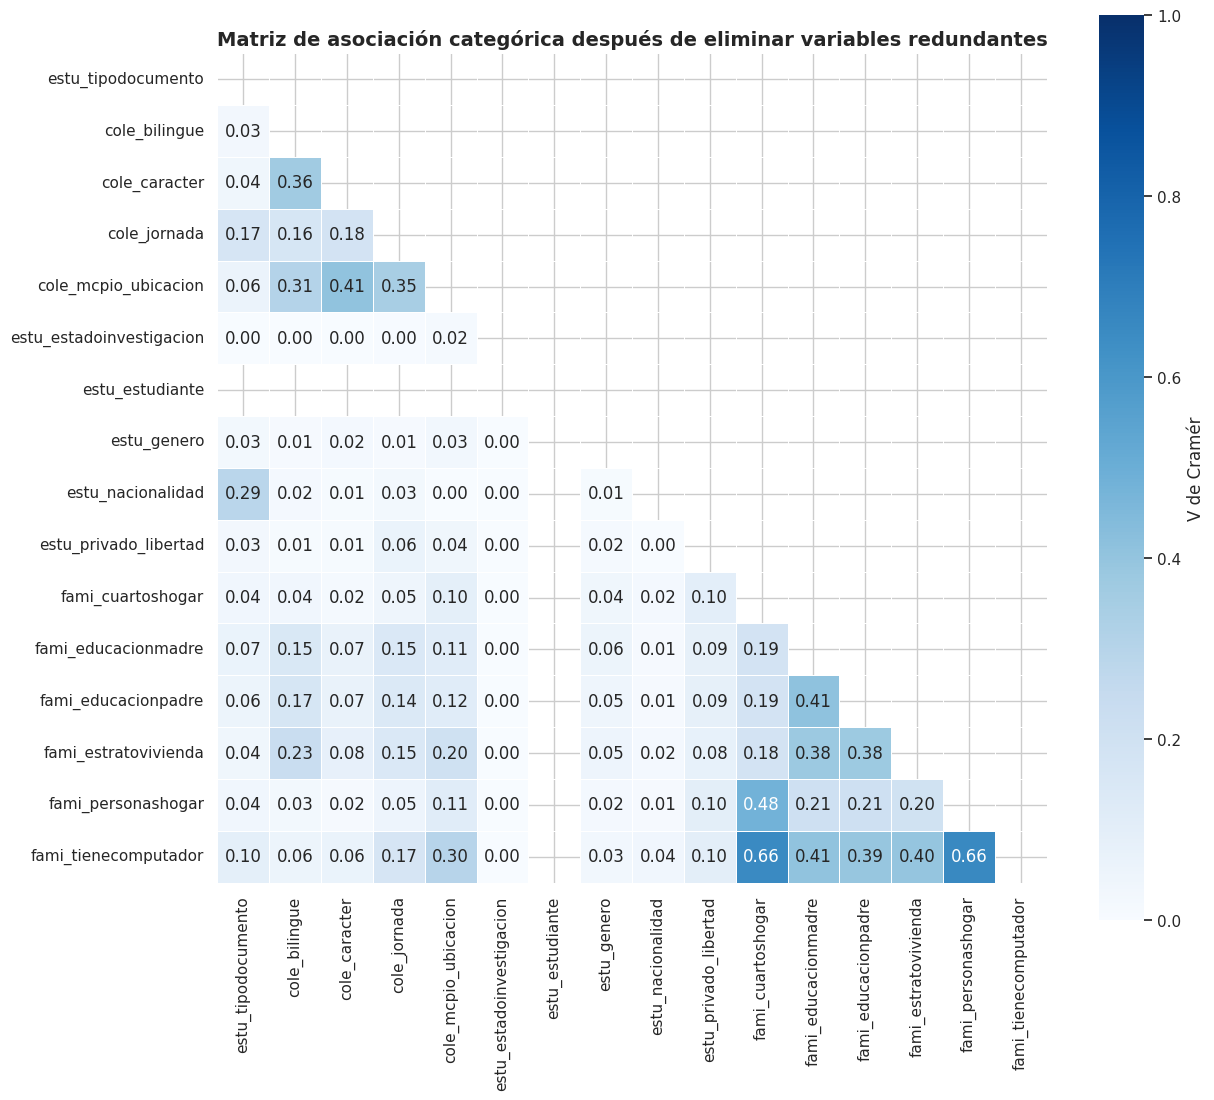

In [27]:
matriz_cramer_resultante = graficar_matriz_cramer_dataset_resultante(
    df=df_reducido,
    columnas_categoricas=columnas_cat_conservadas,
    target_col=target_col,
    excluir_cols=["estu_consecutivo"],
    min_frecuencia_categoria=10,
    triangular=True,
    annot=True,
    cmap="Blues",
    titulo="Matriz de asociación categórica después de eliminar variables redundantes"
)

## 11. Detección de columnas candidatas a eliminación

Se consolidan criterios prácticos para preprocesamiento:

- Constantes.
- Casi constantes.
- Alta cardinalidad extrema.
- Alto porcentaje de nulos.

Estas decisiones se validaran con criterio de negocio y con el diccionario de datos.

In [29]:
# ============================================================
# CELDA 20 - RECOMENDACIONES AUTOMÁTICAS DE PREPROCESAMIENTO
# ============================================================

columnas_muchos_nulos = resumen[resumen["porcentaje_nulos"] >= 30].index.tolist()
columnas_alta_cardinalidad = cat_alta

recomendaciones = []

for col in df.columns:
    if col in cols_constantes:
        accion = "Eliminar"
        razon = "Variable constante; no aporta variabilidad al modelo."
    elif col in cols_casi_constantes:
        accion = "Eliminar"
        razon = "Variable casi constante; una categoría domina al menos el 95% de los registros."
    elif col in columnas_muchos_nulos:
        accion = "Evaluar eliminación o imputación especial"
        razon = "Variable con 30% o más de valores nulos."
    elif col in columnas_alta_cardinalidad:
        accion = "Evaluar codificación avanzada o agrupación"
        razon = "Variable categórica de alta cardinalidad."
    elif col in cat_cols and df[col].isna().sum() > 0:
        accion = "Imputar"
        razon = "Variable categórica con nulos; imputar con moda o categoría 'Desconocido'."
    elif col in num_cols and df[col].isna().sum() > 0:
        accion = "Imputar"
        razon = "Variable numérica con nulos; imputar preferiblemente con mediana."
    else:
        accion = "Conservar"
        razon = "No se identifican problemas críticos en el diagnóstico inicial."

    recomendaciones.append({
        "variable": col,
        "tipo_dato": str(df[col].dtype),
        "nulos": int(df[col].isna().sum()),
        "porcentaje_nulos": round(df[col].isna().mean() * 100, 2),
        "valores_unicos": int(df[col].nunique(dropna=True)),
        "accion_sugerida": accion,
        "justificacion": razon
    })

recomendaciones_df = pd.DataFrame(recomendaciones)
display(recomendaciones_df)


,variable,tipo_dato,nulos,porcentaje_nulos,valores_unicos,accion_sugerida,justificacion
0,periodo,int64,0,0.00,3,Conservar,No se identifican problemas críticos en el dia...
1,estu_tipodocumento,object,0,0.00,15,Conservar,No se identifican problemas críticos en el dia...
2,estu_consecutivo,object,0,0.00,566241,Evaluar codificación avanzada o agrupación,Variable categórica de alta cardinalidad.
3,cole_area_ubicacion,object,1,0.00,2,Imputar,Variable categórica con nulos; imputar con mod...
4,cole_bilingue,object,102581,18.12,2,Imputar,Variable categórica con nulos; imputar con mod...
5,cole_calendario,object,1,0.00,3,Imputar,Variable categórica con nulos; imputar con mod...
6,cole_caracter,object,23569,4.16,4,Imputar,Variable categórica con nulos; imputar con mod...
7,cole_depto_ubicacion,object,1,0.00,33,Imputar,Variable categórica con nulos; imputar con mod...
8,cole_genero,object,1,0.00,3,Imputar,Variable categórica con nulos; imputar con mod...
9,cole_jornada,object,1,0.00,6,Imputar,Variable categórica con nulos; imputar con mod...


In [30]:
columnas_a_eliminar_por_recomendacion = recomendaciones_df[recomendaciones_df['accion_sugerida'] == 'Eliminar']['variable'].tolist()

print("Columnas cuya recomendación es eliminar:")
print(columnas_a_eliminar_por_recomendacion)

Columnas cuya recomendación es eliminar:
['estu_estadoinvestigacion', 'estu_estudiante', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad']


In [31]:
columnas_totales_a_eliminar = list(set(columnas_cat_eliminadas + columnas_a_eliminar_por_recomendacion))

print("Columnas totales candidatas a eliminar (sin repetir):")
print(columnas_totales_a_eliminar)

Columnas totales candidatas a eliminar (sin repetir):
['cole_naturaleza', 'cole_area_ubicacion', 'cole_genero', 'estu_mcpio_presentacion', 'estu_nacionalidad', 'fami_tieneinternet', 'estu_depto_presentacion', 'fami_tieneautomovil', 'cole_depto_ubicacion', 'estu_depto_reside', 'fami_tienelavadora', 'estu_mcpio_reside', 'estu_estudiante', 'estu_pais_reside', 'cole_sede_principal', 'cole_calendario', 'estu_estadoinvestigacion', 'estu_privado_libertad']


** 12. Seleccion final columnas a Eliminar por criterio de negocio **

De las columnas candidatas a eliminar se exluyen aquellas que, son consideradas claves

In [33]:
columnas_a_remover_manualmente = [
    'cole_naturaleza',
    'cole_genero',
    'fami_tieneinternet',
    'cole_calendario'
]

columnas_totales_a_eliminar_actualizada = [
    col for col in columnas_totales_a_eliminar
    if col not in columnas_a_remover_manualmente
]

print("Columnas totales candidatas a eliminar (actualizada sin los elementos solicitados):")
print(columnas_totales_a_eliminar_actualizada)

Columnas totales candidatas a eliminar (actualizada sin los elementos solicitados):
['cole_area_ubicacion', 'estu_mcpio_presentacion', 'estu_nacionalidad', 'estu_depto_presentacion', 'fami_tieneautomovil', 'cole_depto_ubicacion', 'estu_depto_reside', 'fami_tienelavadora', 'estu_mcpio_reside', 'estu_estudiante', 'estu_pais_reside', 'cole_sede_principal', 'estu_estadoinvestigacion', 'estu_privado_libertad']


In [35]:
df_columnas_a_eliminar = pd.DataFrame({
    'columna_a_eliminar': columnas_totales_a_eliminar_actualizada
})
display(df_columnas_a_eliminar)

,columna_a_eliminar
0,cole_area_ubicacion
1,estu_mcpio_presentacion
2,estu_nacionalidad
3,estu_depto_presentacion
4,fami_tieneautomovil
5,cole_depto_ubicacion
6,estu_depto_reside
7,fami_tienelavadora
8,estu_mcpio_reside
9,estu_estudiante


In [37]:
# ============================================================
# CELDA 21 - EXPORTAR RECOMENDACIONES
# ============================================================

df_columnas_a_eliminar.to_csv(RUTA_OUTPUT + NOMBRE_RECOMENDACIONES, index=False, encoding="utf-8-sig")
print("Recomendaciones exportadas en:", RUTA_OUTPUT + NOMBRE_RECOMENDACIONES)


Recomendaciones exportadas en: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/Columas a Eliminar.csv


## 11. Conclusión metodológica del EDA

Este EDA permite tomar decisiones para la siguiente etapa de modelado:

1. Definir columnas a eliminar por baja información, alta cardinalidad o valores faltantes excesivos.
2. Seleccionar estrategias de imputación diferenciadas para variables categóricas y numéricas.
3. Determinar si el target presenta desbalance y si se requieren métricas como F1 macro.
4. Elegir técnicas de codificación apropiadas: One-Hot Encoding para baja cardinalidad, agrupación o codificación avanzada para alta cardinalidad.
5. Preparar el diseño de un pipeline reproducible de preprocesamiento y entrenamiento.